In [ ]:
import pandas as pd
import numpy as np

In [ ]:
df = pd.read_csv('fatal-police-shootings-data.csv')

In [83]:
df

,id,name,date,manner_of_death,armed,age,gender,race,city,state,signs_of_mental_illness,threat_level,flee,body_camera,day_of_week
0,3,Tim Elliot,2015-01-02,shot,gun,53.0,M,A,Shelton,WA,True,attack,Not fleeing,False,Friday
1,4,Lewis Lee Lembke,2015-01-02,shot,gun,47.0,M,W,Aloha,OR,False,attack,Not fleeing,False,Friday
2,5,John Paul Quintero,2015-01-03,shot and Tasered,unarmed,23.0,M,H,Wichita,KS,False,other,Not fleeing,False,Saturday
3,8,Matthew Hoffman,2015-01-04,shot,toy weapon,32.0,M,W,San Francisco,CA,True,attack,Not fleeing,False,Sunday
4,9,Michael Rodriguez,2015-01-04,shot,nail gun,39.0,M,H,Evans,CO,False,attack,Not fleeing,False,Sunday
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5411,5921,William Slyter,2020-06-13,shot,gun,22.0,M,W,Kansas City,MO,False,other,Other,False,Saturday
5412,5922,TK TK,2020-06-13,shot,undetermined,NaN,M,NaN,San Bernardino,CA,False,attack,Not fleeing,False,Saturday
5413,5924,Nicholas Hirsh,2020-06-15,shot,gun,31.0,M,W,Lawrence,KS,False,attack,Car,False,Monday
5414,5926,TK TK,2020-06-16,shot,gun,24.0,M,NaN,Beach Park,IL,False,attack,Not fleeing,False,Tuesday


In [125]:
df['state'].unique()

<StringArray>
['WA', 'OR', 'KS', 'CA', 'CO', 'OK', 'AZ', 'IA', 'PA', 'TX', 'OH', 'LA', 'MT',
 'UT', 'AR', 'IL', 'NV', 'NM', 'MN', 'MO', 'VA', 'NJ', 'IN', 'KY', 'MA', 'NH',
 'FL', 'ID', 'MD', 'NE', 'MI', 'GA', 'TN', 'NC', 'AK', 'NY', 'ME', 'AL', 'MS',
 'WI', 'SC', 'DE', 'DC', 'WV', 'HI', 'WY', 'ND', 'CT', 'SD', 'VT', 'RI']
Length: 51, dtype: str

In [ ]:
pivot_1 = df.pivot_table(
    values='id',
    index='race',
    columns='signs_of_mental_illness',
    aggfunc='count'
)

In [ ]:
pivot_1

In [ ]:
pivot_2 = df.pivot_table(
    values='id',
    index='race',
    columns='signs_of_mental_illness',
    aggfunc='count',
)   #mozna dodac .fillna(0)

In [ ]:
pivot_2['total'] = pivot_2.sum(axis=1)

In [ ]:
pivot_2

In [ ]:
pivot_2['mental_illness_%'] = (
    pivot_2[True] / pivot_2['total']
) * 100

In [ ]:
pivot_2

In [ ]:
df = pd.read_csv('fatal-police-shootings-data.csv')

In [ ]:
df

In [ ]:
df['date'] = pd.to_datetime(df['date'])

In [ ]:
df['day_of_week'] = df['date'].dt.day_name()

In [ ]:
df

In [ ]:
counts = df['day_of_week'].value_counts()

In [64]:
order = [
    'Monday', 'Tuesday', 'Wednesday',
    'Thursday', 'Friday', 'Saturday', 'Sunday'
]

In [65]:
counts = counts.reindex(order)

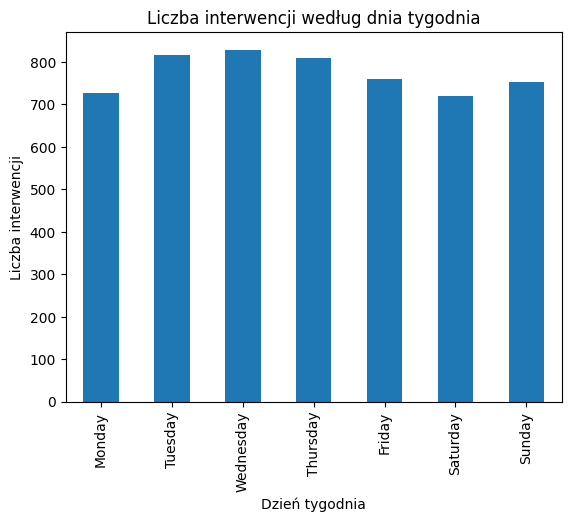

In [66]:
import matplotlib.pyplot as plt

# tworzymy wykres
counts.plot(kind='bar')

# opis wykresu
plt.title('Liczba interwencji według dnia tygodnia')
plt.xlabel('Dzień tygodnia')
plt.ylabel('Liczba interwencji')

# pokazujemy wykres
plt.show()

In [95]:
url = "https://simple.wikipedia.org/wiki/List_of_U.S._states_by_population"

table_1 = pd.read_html(
    url,
    header=0,
    storage_options={"User-Agent": "Mozilla/5.0"}
)

# WYJĘCIE TABELI Z LISTY
df_pop = table_1[0]

# wyciągamy tylko potrzebne kolumny
pop = df_pop[[
    'State',
    'Census population, April 1, 2020 [1][2]'
]].copy()

# zmiana nazw 
pop.columns = ['state', 'population']

# zamiana na liczby
pop['population'] = pop['population'].astype(int)

# sprawdzenie
pop.head()

,state,population
0,California,39538223
1,Texas,30145505
2,Florida,21538187
3,New York,20201249
4,Pennsylvania,13002700


In [94]:
#print(df_pop.columns.tolist())   # sprawdzenie kolumn

In [165]:
url = "https://www.50states.com/abbreviations.htm"

codes_table = pd.read_html(
    url,
    header=0,
    storage_options={"User-Agent": "Mozilla/5.0"}
)

# wybierz właściwą tabelę (np. 0 lub 1)
codes = codes_table[0]

#wybierz kolumny
codes = codes[['US STATE', 'POSTAL ABBREVIATION']]

# zmień nazwy
codes.columns = ['state', 'abbr']

In [166]:
codes

,state,abbr
0,Alabama,AL
1,Alaska,AK
2,Arizona,AZ
3,Arkansas,AR
4,California,CA
5,Colorado,CO
6,Connecticut,CT
7,Delaware,DE
8,Florida,FL
9,Georgia,GA


In [167]:
codes['abbr'].unique()

<StringArray>
['AL', 'AK', 'AZ', 'AR', 'CA', 'CO', 'CT', 'DE', 'FL', 'GA', 'HI', 'ID', 'IL',
 'IN', 'IA', 'KS', 'KY', 'LA', 'ME', 'MD', 'MA', 'MI', 'MN', 'MS', 'MO', 'MT',
 'NE', 'NV', 'NH', 'NJ', 'NM', 'NY', 'NC', 'ND', 'OH', 'OK', 'OR', 'PA', 'RI',
 'SC', 'SD', 'TN', 'TX', 'UT', 'VT', 'VA', 'WA', 'WV', 'WI', 'WY']
Length: 50, dtype: str

In [115]:
# liczba incydentów w każdym stanie
incidents = df['state'].value_counts().reset_index()

In [107]:
incidents.head()

,state,incidents
0,CA,799
1,TX,481
2,FL,350
3,AZ,254
4,CO,195


In [108]:
codes.head()

,state,abbr
0,California,CA
1,Colorado,CO
2,Delaware,DE
3,Hawaii,HI
4,Kansas,KS


In [110]:
# usuwamy spacje i ujednolicamy tekst
incidents['state'] = incidents['state'].str.strip()
pop['state'] = pop['state'].str.strip()
codes['state'] = codes['state'].str.strip()

In [168]:
# zmieniamy nazwę kolumny na abbr (bo to są skróty!)
incidents = incidents.rename(columns={'state': 'abbr'})

In [186]:
# łączymy incydenty ze skrótami
df_final = incidents.merge(codes, on='abbr', how='left')

In [187]:
df_final

,abbr,count,state
0,CA,799,California
1,TX,481,Texas
2,FL,350,Florida
3,AZ,254,Arizona
4,CO,195,Colorado
5,GA,182,Georgia
6,OK,164,Oklahoma
7,NC,156,North Carolina
8,OH,155,Ohio
9,WA,152,Washington


In [188]:
df_final = df_final.merge(pop, on='state', how='left')

In [189]:
df_final

,abbr,count,state,population
0,CA,799,California,39538223.0
1,TX,481,Texas,30145505.0
2,FL,350,Florida,21538187.0
3,AZ,254,Arizona,7151502.0
4,CO,195,Colorado,5773714.0
5,GA,182,Georgia,10711908.0
6,OK,164,Oklahoma,3959353.0
7,NC,156,North Carolina,10439388.0
8,OH,155,Ohio,11799448.0
9,WA,152,Washington,7705281.0


In [190]:
df_final['incidents_per_1000'] = (
    df_final['count'] / df_final['population']
) * 1000

In [191]:
df_final = df_final.dropna(subset=['population'])

In [192]:
df_final

,abbr,count,state,population,incidents_per_1000
0,CA,799,California,39538223.0,0.020208
1,TX,481,Texas,30145505.0,0.015956
2,FL,350,Florida,21538187.0,0.016250
3,AZ,254,Arizona,7151502.0,0.035517
4,CO,195,Colorado,5773714.0,0.033774
5,GA,182,Georgia,10711908.0,0.016990
6,OK,164,Oklahoma,3959353.0,0.041421
7,NC,156,North Carolina,10439388.0,0.014943
8,OH,155,Ohio,11799448.0,0.013136
9,WA,152,Washington,7705281.0,0.019727


In [193]:
df_final.sort_values('incidents_per_1000', ascending=False)

,abbr,count,state,population,incidents_per_1000
35,AK,39,Alaska,733391.0,0.053178
14,NM,106,New Mexico,2117522.0,0.050059
6,OK,164,Oklahoma,3959353.0,0.041421
3,AZ,254,Arizona,7151502.0,0.035517
4,CO,195,Colorado,5773714.0,0.033774
18,NV,96,Nevada,3104614.0,0.030922
32,WV,54,West Virginia,1793716.0,0.030105
38,MT,31,Montana,1084225.0,0.028592
25,AR,83,Arkansas,3011524.0,0.027561
44,WY,14,Wyoming,576851.0,0.024270
